In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    StackingClassifier
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.inspection import permutation_importance

In [2]:
RANDOM_STATE = 42
DATASET_PATH = 'S06-hw-dataset-02.csv'
ARTIFACTS_DIR = Path('artifacts')
FIGURES_DIR = ARTIFACTS_DIR / 'figures'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATASET_PATH)

In [3]:
df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
0,1,-0.149235,-2.826966,-0.522901,-4.198449,1.364943,0.815043,-1.195518,-1.932232,2.396353,...,-0.159323,0.448015,0.572745,0.149916,0.878392,-0.679733,1.412751,0.421883,9.217167,1
1,2,-1.966180,-4.877542,0.268367,-9.607791,0.097149,1.347185,-3.872575,-0.395117,1.710068,...,-0.389212,1.383794,0.169876,0.043969,-0.963545,1.006643,-2.488690,9.590124,24.772826,0
2,3,-0.555964,-0.999920,0.209673,-14.119498,-1.808950,-0.006222,-4.651108,0.911944,-0.289037,...,-1.383970,3.044321,-0.182864,1.425649,-8.418598,-4.629754,-0.439798,0.555919,41.800517,0
3,4,-2.049199,-5.600713,-1.664677,-6.263893,-5.224455,0.848351,1.407210,-0.542080,0.119102,...,-2.713080,2.762637,-0.520796,-0.142455,1.668338,2.292810,-10.744916,11.476977,65.315860,0
4,5,-0.220556,4.889479,-2.235840,6.450046,0.774389,-2.382625,2.584816,4.211856,-0.317889,...,-1.302872,2.478862,1.528610,1.098131,3.547087,2.517757,-9.364106,-1.078404,93.017870,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64
 6   f06      18000 non-null  float64
 7   f07      18000 non-null  float64
 8   f08      18000 non-null  float64
 9   f09      18000 non-null  float64
 10  f10      18000 non-null  float64
 11  f11      18000 non-null  float64
 12  f12      18000 non-null  float64
 13  f13      18000 non-null  float64
 14  f14      18000 non-null  float64
 15  f15      18000 non-null  float64
 16  f16      18000 non-null  float64
 17  f17      18000 non-null  float64
 18  f18      18000 non-null  float64
 19  f19      18000 non-null  float64
 20  f20      18000 non-null  float64
 21  f21      180

In [5]:
df.describe()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,...,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,1.800000e+04,18000.000000
mean,9000.500000,-0.418555,0.614251,0.004559,0.059000,0.405086,0.012123,-0.283473,-0.266880,0.255107,...,-0.139825,0.108568,0.007238,0.000904,-0.716862,-0.274520,0.344991,1.517339,2.576221e+01,0.262611
std,5196.296758,2.178005,3.926778,1.000134,5.713672,2.497581,0.987226,2.193891,2.081431,2.225776,...,2.148834,2.234315,0.997861,1.002115,3.913704,2.482890,4.927315,10.630850,5.423748e+01,0.440065
min,1.000000,-10.014698,-15.510323,-4.031762,-23.663256,-12.289308,-3.741536,-9.591425,-8.293319,-13.655742,...,-8.171469,-9.214171,-3.937091,-3.963063,-19.389908,-10.031559,-20.768452,-107.788145,1.895059e-07,0.000000
25%,4500.750000,-1.866134,-2.048192,-0.673127,-3.544964,-1.153000,-0.653090,-1.743214,-1.688121,-1.177480,...,-1.589638,-1.369266,-0.663023,-0.684164,-3.286842,-1.897893,-2.752685,-2.018750,1.226029e+00,0.000000
50%,9000.500000,-0.465100,0.600291,0.003581,0.072826,0.485625,0.018765,-0.251263,-0.302463,0.350739,...,-0.204785,0.158715,0.001912,-0.003157,-0.618472,-0.339901,0.573153,0.318011,6.581865e+00,0.000000
75%,13500.250000,0.966393,3.229850,0.671390,3.689490,2.075739,0.689304,1.195481,1.109589,1.764113,...,1.254595,1.600671,0.677296,0.676558,1.948803,1.314163,3.649794,4.212111,2.576847e+01,1.000000
max,18000.000000,9.589975,15.417329,3.817025,26.815691,10.665184,3.528280,7.794627,8.892834,8.699629,...,9.290667,8.794320,4.341030,3.781380,14.065595,10.639974,20.226291,94.891804,1.103449e+03,1.000000


In [6]:
df = df.drop(columns=['id'])

print(f"Shape: {df.shape}")
print("Target distribution:")
print(df['target'].value_counts(normalize=True))

X = df.drop(columns='target')
y = df['target']

Shape: (18000, 38)
Target distribution:
target
0    0.737389
1    0.262611
Name: proportion, dtype: float64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (13500, 37), Test size: (4500, 37)


***Фиксация random_state (seed) гарантирует воспроизводимость эксперимента, позволяя получать идентичное разбиение данных при каждом запуске кода. Стратификация обеспечивает сохранение пропорции классов в обучающей и тестовой выборках, что критично для объективной оценки модели, особенно при наличии дисбаланса.***

In [8]:
results = {}
search_summaries = {}

def evaluate_model(name, model, X_test, y_test, y_pred, y_proba):
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    print(f"[{name}] Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f}")
    return {"Accuracy": acc, "F1": f1, "ROC-AUC": roc}

In [9]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
y_proba = dummy.predict_proba(X_test)[:, 1]
results['Dummy'] = evaluate_model('Dummy', dummy, X_test, y_test, y_pred, y_proba)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
y_proba = pipe_lr.predict_proba(X_test)[:, 1]
results['LogReg'] = evaluate_model('LogReg', pipe_lr, X_test, y_test, y_pred, y_proba)

[Dummy] Accuracy: 0.7373 | F1: 0.0000 | ROC-AUC: 0.5000
[LogReg] Accuracy: 0.8162 | F1: 0.5717 | ROC-AUC: 0.8009


***DummyClassifier служит "точкой нуля", показывая качество простейшего правила (например, всегда предсказывать самый частый класс), выше которого обязана быть любая осмысленная модель. LogisticRegression выступает в роли сильного линейного базового решения: если её метрики близки к продвинутым ансамблям, значит, зависимости в данных преимущественно линейны и не требуют сложных моделей.***

In [10]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 20],
    'ccp_alpha': [0.0, 0.001, 0.01]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_params, cv=cv_strategy, scoring='roc_auc', n_jobs=-1
)
dt_grid.fit(X_train, y_train)
results['DecisionTree'] = evaluate_model(
    'DecisionTree', dt_grid.best_estimator_, X_test, y_test, 
    dt_grid.predict(X_test), dt_grid.predict_proba(X_test)[:, 1]
)
search_summaries['DecisionTree'] = {
    'best_params': dt_grid.best_params_, 
    'best_cv_score': dt_grid.best_score_
}

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params, cv=cv_strategy, scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
results['RandomForest'] = evaluate_model(
    'RandomForest', rf_grid.best_estimator_, X_test, y_test, 
    rf_grid.predict(X_test), rf_grid.predict_proba(X_test)[:, 1]
)
search_summaries['RandomForest'] = {
    'best_params': rf_grid.best_params_, 
    'best_cv_score': rf_grid.best_score_
}

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params, cv=cv_strategy, scoring='roc_auc', n_jobs=-1
)
gb_grid.fit(X_train, y_train)
results['GradientBoosting'] = evaluate_model(
    'GradientBoosting', gb_grid.best_estimator_, X_test, y_test, 
    gb_grid.predict(X_test), gb_grid.predict_proba(X_test)[:, 1]
)
search_summaries['GradientBoosting'] = {
    'best_params': gb_grid.best_params_, 
    'best_cv_score': gb_grid.best_score_
}

estimators = [
    ('dt', dt_grid.best_estimator_),
    ('rf', rf_grid.best_estimator_),
    ('gb', gb_grid.best_estimator_)
]
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=cv_strategy
)
stacking_clf.fit(X_train, y_train)

y_pred = stacking_clf.predict(X_test)
y_proba = stacking_clf.predict_proba(X_test)[:, 1]
results['Stacking'] = evaluate_model('Stacking', stacking_clf, X_test, y_test, y_pred, y_proba)

[DecisionTree] Accuracy: 0.8322 | F1: 0.6535 | ROC-AUC: 0.8397
[RandomForest] Accuracy: 0.8909 | F1: 0.7551 | ROC-AUC: 0.9287
[GradientBoosting] Accuracy: 0.9042 | F1: 0.8015 | ROC-AUC: 0.9258
[Stacking] Accuracy: 0.9104 | F1: 0.8186 | ROC-AUC: 0.9310


In [11]:
results_df = pd.DataFrame(results).T.sort_values(by='ROC-AUC', ascending=False)
print(results_df)

best_model_name = results_df.index[0]
print(f"\nЛучшая модель: {best_model_name}")

if best_model_name == 'Stacking':
    best_model = stacking_clf
elif best_model_name == 'GradientBoosting':
    best_model = gb_grid.best_estimator_
elif best_model_name == 'RandomForest':
    best_model = rf_grid.best_estimator_
elif best_model_name == 'DecisionTree':
    best_model = dt_grid.best_estimator_
else:
    best_model = pipe_lr

                  Accuracy        F1   ROC-AUC
Stacking          0.910444  0.818550  0.930986
RandomForest      0.890889  0.755112  0.928720
GradientBoosting  0.904222  0.801474  0.925827
DecisionTree      0.832222  0.653511  0.839702
LogReg            0.816222  0.571724  0.800890
Dummy             0.737333  0.000000  0.500000

Лучшая модель: Stacking


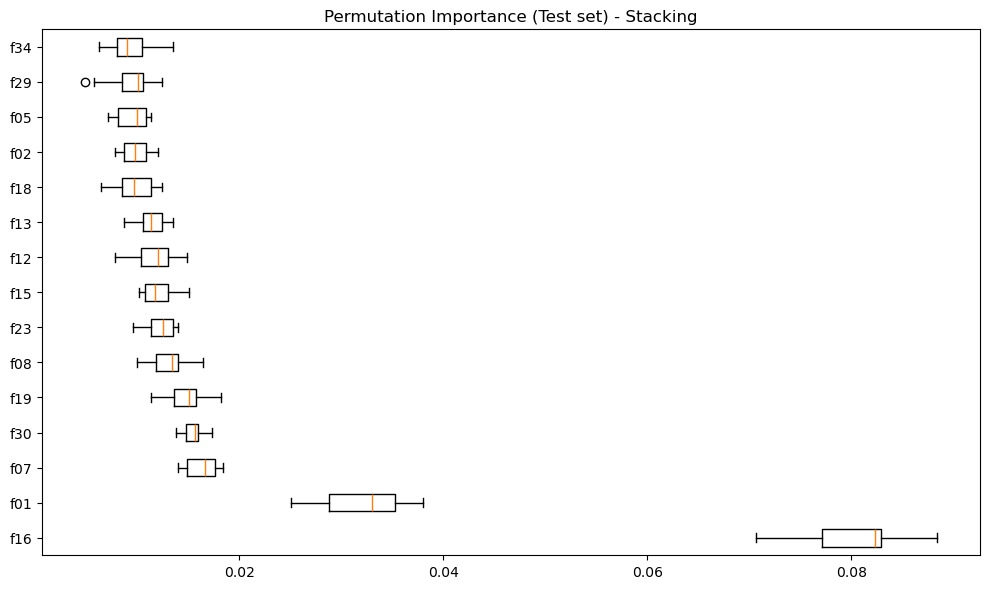

In [12]:
perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

sorted_idx = perm_importance.importances_mean.argsort()[::-1]
top_features = sorted_idx[:15]

plt.figure(figsize=(10, 6))
plt.boxplot(
    perm_importance.importances[top_features].T,
    vert=False,
    tick_labels=X.columns[top_features]
)
plt.title(f"Permutation Importance (Test set) - {best_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance.png')
plt.show()

***Интерпретация важности признаков График permutation importance показывает, что наибольшее влияние на результат оказывают признаки f16 и f01, так как их случайное перемешивание приводит к самому сильному падению метрики ROC-AUC.***

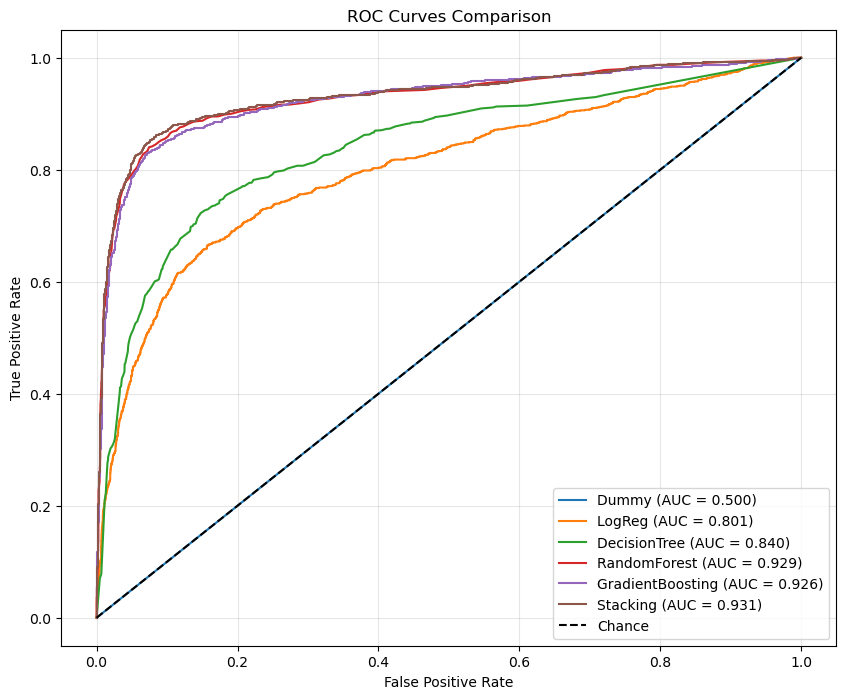

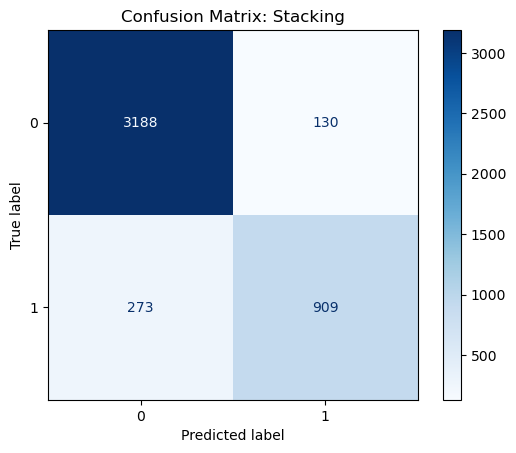

In [13]:
plt.figure(figsize=(10, 8))

models_map = {
    'Dummy': dummy,
    'LogReg': pipe_lr,
    'DecisionTree': dt_grid.best_estimator_,
    'RandomForest': rf_grid.best_estimator_,
    'GradientBoosting': gb_grid.best_estimator_,
    'Stacking': stacking_clf
}

for name, model in models_map.items():
    y_p = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_p)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig(FIGURES_DIR / 'roc_curves_comparison.png')
plt.show()

cm = confusion_matrix(y_test, best_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.savefig(FIGURES_DIR / 'confusion_matrix_best.png')
plt.show()

In [14]:
results_df.to_json(ARTIFACTS_DIR / 'metrics_test.json', orient='index', indent=4)

with open(ARTIFACTS_DIR / 'search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=4, default=str)

joblib.dump(best_model, ARTIFACTS_DIR / 'best_model.joblib')

meta = {
    "best_model_name": best_model_name,
    "dataset": DATASET_PATH,
    "metrics": results[best_model_name],
    "random_state": RANDOM_STATE
}
with open(ARTIFACTS_DIR / 'best_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=4)

In [16]:
joblib.dump(gb_grid.best_estimator_, ARTIFACTS_DIR / 'best_model.joblib')

['artifacts\\best_model.joblib']